# Unit End 4: Home Loan Data Analysis

## Problem Scenario
For a safe and secure lending experience, it's important to analyze the past data. In this project, you have to build a deep learning model to predict the chance of default for future loans using historical data. As you will see, this dataset is highly imbalanced and includes a lot of features that make this problem more challenging.

### Problem Objective
Create a model that predicts whether or not an applicant will be able to repay a loan using historical data

## Notebook Setup

### Imports

In [ ]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    precision_recall_curve, 
    roc_curve,
    auc
)
from sklearn.utils import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Input, BatchNormalization
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
from tensorflow.keras.regularizers import l2

np.random.seed(320)
tf.random.set_seed(320)

### Configuration

In [2]:
# Configure GPU settings
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Use only GPU 0
        tf.config.set_visible_devices(gpus[0], 'GPU')

        # Enable memory growth
        tf.config.experimental.set_memory_growth(gpus[0], True)

        print(f'Using GPU: {gpus[0]}')
        print('Memory growth enabled')

    except RuntimeError as e:
        print(e)

In [3]:
pd.set_option("display.max_columns", None)

## 1. EDA

### 1.1 Load Data

In [4]:
df = pd.read_csv("./data/Home_Loan.csv")
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
df.sample(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
87557,201623,0,Cash loans,M,N,Y,0,180000.0,599472.0,30739.5,517500.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.030755,-15631,-1523,-1412.0,-3958,NaN,1,1,0,1,1,0,Laborers,2.0,2,2,SATURDAY,13,0,0,0,0,1,1,Business Entity Type 3,NaN,0.574530,0.788681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0
129809,250563,0,Cash loans,F,N,Y,0,202500.0,1494486.0,48339.0,1305000.0,Unaccompanied,State servant,Higher education,Married,House / apartment,0.010500,-19771,-5844,-7504.0,-3174,NaN,1,1,0,1,1,0,Managers,2.0,3,3,FRIDAY,15,0,0,0,0,0,0,Other,0.675828,0.639285,0.583238,0.2691,0.1641,0.9856,0.8028,0.0489,0.28,0.2414,0.3333,0.3750,0.0832,0.2169,0.2745,0.0116,0.0465,0.2742,0.1703,0.9856,0.8105,0.0494,0.2820,0.2414,0.3333,0.3750,0.0851,0.2369,0.2860,0.0117,0.0492,0.2717,0.1641,0.9856,0.8054,0.0492,0.28,0.2414,0.3333,0.3750,0.0847,0.2206,0.2795,0.0116,0.0475,reg oper account,block of flats,0.2260,"Stone, brick",No,1.0,1.0,1.0,1.0,-121.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
226257,362062,1,Cash loans,F,Y,Y,2,315000.0,291915.0,20889.0,252000.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.007274,-13424,-500,-726.0,-1354,14.0,1,1,0,1,0,0,NaN,4.0,2,2,SUNDAY,12,0,0,0,0,0,0,Other,0.419682,0.073247,0.771362,0.1113,0.0814,0.9856,0.8028,0.0204,0.12,0.1034,0.3333,0.3750,0.0263,0.0908,0.1114,0.0000,0.0000,0.1134,0.0845,0.9856,0.8105,0.0206,0.1208,0.1034,0.3333,0.3750,0.0269,0.0992,0.1161,0.0000,0.0000,0.1124,0.0814,0.9856,0.8054,0.0206,0.12,0.1034,0.3333,0.3750,0.0268

Features of Interest that stand out at first glance:
- REGION_POPULATION_RELATIVE - What do these 6 digit decimals represent?
- DAYS_ FEATURES - All the "DAYS_" features are negative, keep this into account
- OCCUPATION_TYPE, EXT_*, *_AVG, *_MODE, *_MEDI, AMT_REQ_* - Noticed some "NaN" input data on all these features, Check this later when looking for missing values
- FLAG - First few flag features were in Y/N format, the others are 0/1 but they act as booleans nonetheless

In [6]:
df_dictionary = pd.read_csv("./data/Home_Loan_Dictionary.csv", encoding="latin-1")
df_dictionary

,Column no.,Variable Name,Description
0,1,SK_ID_CURR,Unique identifier for each client.
1,2,TARGET,"Whether the loan was repaid (1 for yes, 0 for ..."
2,3,NAME_CONTRACT_TYPE,"Type of loan contract (e.g., Cash loans, Revol..."
3,4,CODE_GENDER,Gender of the applicant.
4,5,FLAG_OWN_CAR,Whether the applicant owns a car (Yes/No).
...,...,...,...
115,116,AMT_REQ_CREDIT_BUREAU_DAY,Number of inquiries to the Credit Bureau in th...
116,117,AMT_REQ_CREDIT_BUREAU_WEEK,Number of inquiries to the Credit Bureau in th...
117,118,AMT_REQ_CREDIT_BUREAU_MON,Number of inquiries to the Credit Bureau in th...
118,119,AMT_REQ_CREDIT_BUREAU_QRT,Number of inquiries to the Credit Bureau in th...


In [7]:
#Check the REGION_POPULATION_RELATIVE
reg_pop_rel = df_dictionary[df_dictionary["Variable Name"] == "REGION_POPULATION_RELATIVE"]
print(reg_pop_rel["Description"].item())

Normalized population of the region where the client lives.


Now seeing that this is normalized data we can understand this most likely means each region sums up to 1. We don't see a clear indication of what the regions are derived from yet.

### 1.2 Evaluate Data

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [9]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

In [10]:
missing = df.isna().sum(skipna=False)
missing[missing > 0]

AMT_ANNUITY                       12
AMT_GOODS_PRICE                  278
NAME_TYPE_SUITE                 1292
OWN_CAR_AGE                   202929
OCCUPATION_TYPE                96391
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
Length: 67, dtype: int64

Quick glance at the data we see there are a lot of missing values, and we cant see them all. Let's try to concatenate and sort this somehow. How much is missing? We have 122 total features, and a dictionary explanation of these features when needed. We added this dictionary table as a variable for reference later. We did notice SK_ID_CURR was not incrementally fixed with the count of rows in our dataset. It is an identifier, but let's quickly see if there are any duplicates.

In [11]:
#Check top 20 features missing by percent, we know there are 67 features missing data
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(f"Percentage of Top 20 most missing data features")
missing_percent.head(20)

Percentage of Top 20 most missing data features


COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MEDI              67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64

There is A LOT of sparse data on some of these features. This is very hard to consider putting into our model. The features mainly missing look to be aggregations of base features; COMMON_AREA, NONLIVINGAPARTMENTS, FONDKAPREMONT, LIVINGAPARTMENTS, FLOORSMIN, YEARS_BUILD, OWN_CAR_AGE, and LANDAREA. Let's consider creating a base model where missing > 55% we drop it. We might be able to impute with at least 45% data present. 

In [12]:
#Check if any IDs are duplicated
df[df["SK_ID_CURR"].duplicated(keep=False) == True]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR


In [13]:
df.sample(10).select_dtypes(include="str")

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
156320,Cash loans,F,N,N,Unaccompanied,Working,Higher education,Widow,House / apartment,Core staff,MONDAY,Government,NaN,block of flats,"Stone, brick",No
180116,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Separated,House / apartment,NaN,SATURDAY,Other,reg oper account,block of flats,Panel,No
216272,Cash loans,F,N,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,Sales staff,THURSDAY,Self-employed,org spec account,block of flats,Panel,No
256305,Cash loans,M,Y,Y,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,NaN,THURSDAY,XNA,NaN,NaN,NaN,NaN
168213,Cash loans,F,N,N,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Low-skill Laborers,SATURDAY,Self-employed,NaN,NaN,NaN,NaN
5610,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Cooking staff,WEDNESDAY,Other,NaN,NaN,NaN,NaN
167989,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,THURSDAY,Electricity,NaN,block of flats,"Stone, brick",No
201203,Revolving loans,F,Y,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Core staff,FRIDAY,Kindergarten,NaN,NaN,NaN,NaN
172784,Cash loans,F,Y,Y,Unaccompanied,State servant,Secondary / secondary special,Married,House / apartment,Laborers,SUNDAY,Postal,reg oper account,block of flats,Panel,No
63797,Cash loans,F,N,N,Unaccompanied,Pensioner,Higher education,Married,House / apartment,NaN,TUESDAY,XNA,reg oper account,block of flats,"Stone, brick",No


### 1.3 Countplot of Target

Dictionary Desciption: Whether the loan was repaid (1 for yes, 0 for no).
Defaulted percentage: 8.0729%


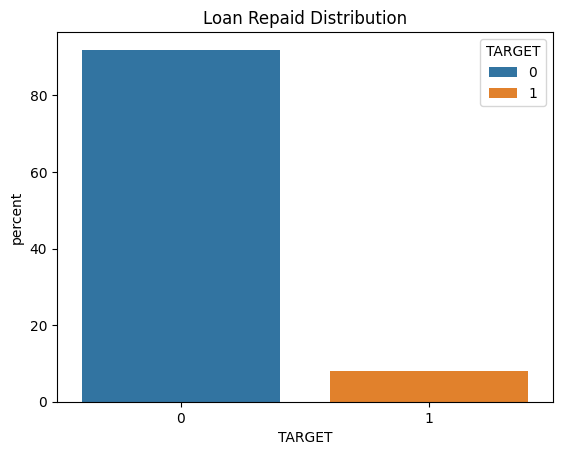

In [14]:
# Check our target column
print(f"Dictionary Desciption: {df_dictionary[df_dictionary["Variable Name"] == "TARGET"]["Description"].item()}")
print(f"Defaulted percentage: {(df['TARGET'].mean() * 100):.4f}%")
plt.title("Loan Repaid Distribution")
sns.countplot(x="TARGET", data=df, stat="percent", hue="TARGET")
plt.show()

Looking at our target column for how many defaults we have we can see there's a large disproportion of unpaid/defaulted vs repaid loans. Only ~8% are defaulted, we need to remember this for evaluation.

### 1.4 Boxplot of Income

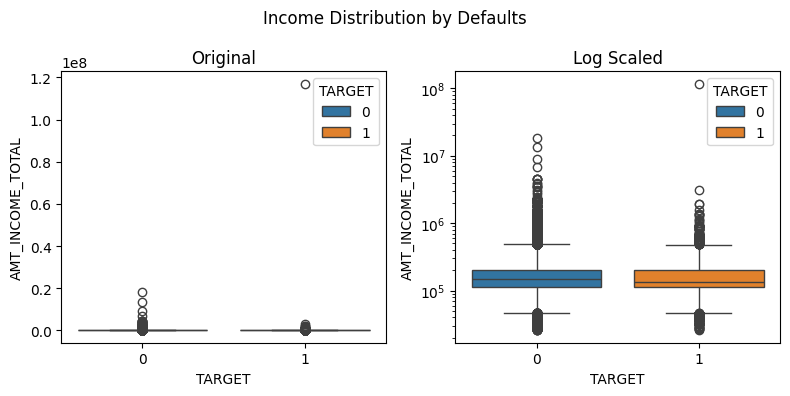

In [15]:
# Plot income vs target feature
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].set_title("Original")
sns.boxplot(x="TARGET", y="AMT_INCOME_TOTAL", data=df, ax=axes[0], hue="TARGET")

# Our first plot is skewed very far, let's use log scale
axes[1].set_title("Log Scaled")
sns.boxplot(x="TARGET", y="AMT_INCOME_TOTAL", data=df, ax=axes[1], hue="TARGET", log_scale=True)

plt.suptitle("Income Distribution by Defaults")
plt.tight_layout()
plt.show()

Seeing the plots for Income vs Defaulted Loans we can see that the averages are basically the same this tells us, income doesn't have a significant impact on whether a loan is defaulted.

### 1.5 H Bar Correlations

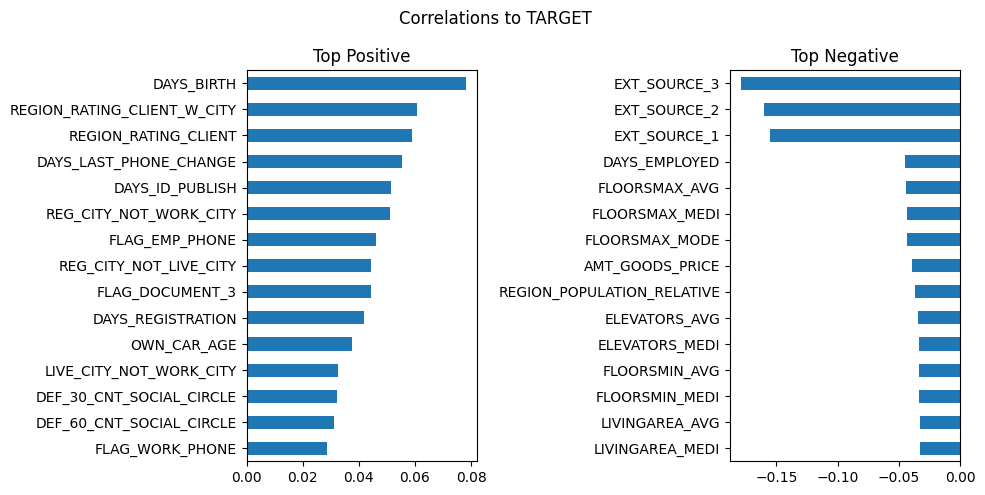

In [16]:
# Plot barplot correlations to TARGET
target_corr = df.corr(numeric_only=True)["TARGET"].sort_values(ascending=False).drop("TARGET")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#Top Positive Correlations
axes[0].set_title("Top Positive")
target_corr.head(15).plot(kind="barh", ax=axes[0]).invert_yaxis()

#Top Negative Correlations
axes[1].set_title("Top Negative")
target_corr.tail(15).plot(kind="barh", ax=axes[1])

plt.suptitle("Correlations to TARGET")
plt.tight_layout()
plt.show()

This plot is very powerful in helping us explain our data and situation with all these features. Let's check the description of our top correlations to get a better understanding of what we are looking at. Now that we have our strongest correlated features, we need to protect these features even if they are part of our missing data from earlier. Lucky for us, even up to our top 5 correlations they aren't the same features so we can still drop them.

In [17]:
# Write out description of top positive and negative correlations
top_corr_features = target_corr.head(3).index
top_corr_features = top_corr_features.append(target_corr.tail(3).index).to_list()
print(top_corr_features)

# df_dictionary[df_dictionary["Variable Name"].isin(top_corr_features.to_list())]
df_dictionary[df_dictionary["Variable Name"].isin(top_corr_features)]["Description"].values

['DAYS_BIRTH', 'REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


<StringArray>
['Age of the client in days (from birth to the application date).',
                    'Rating of the region where the client lives.',
           'Rating of the region and city where the client lives.']
Length: 3, dtype: str

We Notice the EXT_SOURCE features aren't available but based on the names and research we can determine these are most likely external risk scores. We researched and discovered these can be predictable and a good indicator of predicting aa user defaulting on a loan. 

In [18]:
#Check the data in our missing dict features
df[["EXT_SOURCE_3", "EXT_SOURCE_2", "EXT_SOURCE_1"]].sample(10)

,EXT_SOURCE_3,EXT_SOURCE_2,EXT_SOURCE_1
192753,0.297087,0.410743,0.439670
30015,0.332851,0.626221,0.481256
48120,0.846378,0.488097,NaN
168796,0.526295,0.553752,0.304288
300190,0.524496,0.584771,NaN
244646,0.375711,0.345016,0.306976
268222,0.459690,0.393266,NaN
124587,0.572683,0.597607,0.133616
249728,0.607557,0.516391,0.345587
211155,NaN,0.359288,NaN


## 2. Experiment 1: Design Baseline Model

### 2.1 Baseline Pipeline
- Drop high missing/sparse features
- Create our TARGET variable
- Impute using SimpleImputer
- Encode using OneHot and Unknown
- Scale with StandardScaler

In [19]:
#Get columns with 58% missing data 
high_missing_cols = missing_percent[missing_percent > 58].index #Ext source 1 is an important feature correlation, we want to keep this in

#Create our df copy for baseline model and drop sparse data
df_baseline = df.copy(deep=True).drop(columns=high_missing_cols)
df_baseline


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,YEARS_BEGINEXPLUATATION_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,LIVINGAREA_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,YEARS_BEGINEXPLUATATION_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.9722,0.00,0.0690,0.0833,0.0190,0.0000,0.0252,0.9722,0.0000,0.0690,0.0833,0.0198,0.0000,0.0250,0.9722,0.00,0.0690,0.0833,0.0193,0.0000,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.9851,0.08,0.0345,0.2917,0.0549,0.0098,0.0924,0.9851,0.0806,0.0345,0.2917,0.0554,0.0000,0.0968,0.9851,0.08,0.0345,0.2917,0.0558,0.0100,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,1,1,0,

In [20]:
# Separate our TARGET
X = df_baseline.drop("TARGET", axis=1)
y = df_baseline["TARGET"]

#train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=320
)

print(f"Shape of X train: {X_train.shape}")
print(f"Shape of X test: {X_test.shape}")
print(f"Shape of y train: {y_train.shape}")
print(f"Shape of y test: {y_test.shape}")


Shape of X train: (246008, 98)
Shape of X test: (61503, 98)
Shape of y train: (246008,)
Shape of y test: (61503,)


In [21]:
#Collect our dtypes for safe pipelining
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["str"]).columns

#Numerical Pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

#Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

#Preprocess
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

We use sklearn's pipeline, this keeps our data leak free if done correctly, clean practice, easier deployment.

NOTE: Using median for numerical pipeline because we saw heavy amounts of outliers from our boxplot, median won't be affected as heavily opposed to the defaulted mean

In [22]:
#Transform our data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape of training data: {X_train_processed.shape}")
print(f"Shape of test data: {X_test_processed.shape}")

Shape of training data: (246008, 224)
Shape of test data: (61503, 224)


### 2.2 Design Baseline Model
- Use BinaryCrossentrophy (Our TARGET is 0/1)
- ADAM optimizer

In [23]:
input_dim = X_train_processed.shape[1]  #Input Dim
dropout = 0.2
output_dim = 1  #Output Filter size
learning_rate = 1e-3    #LR for fine-tuning
layer_activation = "relu"

model = Sequential([
    Input((input_dim,)),
    Dropout(dropout),
    Dense(128, activation=layer_activation),
    Dense(64, activation=layer_activation),
    Dropout(dropout),
    Dense(output_dim, activation='sigmoid')  #TARGET is binary
])

model.compile(
    optimizer = tf.optimizers.Adam(learning_rate=learning_rate),
    loss = "binary_crossentropy",
    metrics = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        28,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,121 (145.00 KB)

 Trainable params: 37,121 (145.00 KB)

 Non-trainable params: 0 (0.00 B)

We chose this model architecture because dense layers are very good at taking a lot of features and combining them to learn complex combinations. In the summation of a multitude of features it can also excel at classification tasks which is also why our main output is a Dense layer. Dense layers are able to take in all features at once instead of relying on breaking down data for patterns.

RNNs are very good for sequential and time-series dependent data. We don't use them here because this data is a static snapshot in time. We treat each user as an independent data point in this snapshot of time we don't get a clear historic analysis of each user's patterns.

Convolutional Layers are very good for spatial data i.e. images, they learn from local patterns to classify/shape data.

### 2.3 Train Callbacks

In [24]:
callbacks = [
    ModelCheckpoint(
        './models/home_loan_baseline.keras',
        save_best_only=True,
        monitor='val_auc',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    TensorBoard(
        log_dir='./logs/home_loan_baseline',
        histogram_freq=1,
        write_graph=True
    )
]

### 2.4 Train Baseline Model

In [25]:
history = model.fit(
    X_train_processed,  #training data
    y_train,    #Target data
    validation_split=0.2,
    epochs=20,
    batch_size=1024,    #246008 training rows
    verbose=1,
    callbacks=callbacks
)


Epoch 1/20
190/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8303 - auc: 0.5849 - loss: 0.3957 - precision: 0.0786 - recall: 0.1059
Epoch 1: val_auc improved from None to 0.73251, saving model to ./models/home_loan_baseline.keras

Epoch 1: finished saving model to ./models/home_loan_baseline.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8998 - auc: 0.6460 - loss: 0.2980 - precision: 0.0790 - recall: 0.0226 - val_accuracy: 0.9194 - val_auc: 0.7325 - val_loss: 0.2547 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
185/193 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9196 - auc: 0.7047 - loss: 0.2633 - precision: 0.1475 - recall: 2.3886e-04
Epoch 2: val_auc improved from 0.73251 to 0.73861, saving model to ./models/home_loan_baseline.keras

Epoch 2: finished saving model to ./models/home_loan_baseline.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9191 - auc: 0.7083 - loss: 0.2612 - precision: 0.1471 - recall: 3.1456e-04 - val_accuracy: 

### 2.5 CM Base Evaluation

1922/1922 ━━━━━━━━━━━━━━━━━━━━ 1s 529us/step
Test samples: 61503
Prediction distribution:
  Actual:    Counter({0: 56538, 1: 4965})
  Predicted: Counter({np.int64(0): 61488, np.int64(1): 15})
Classification Report: 
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.53      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503



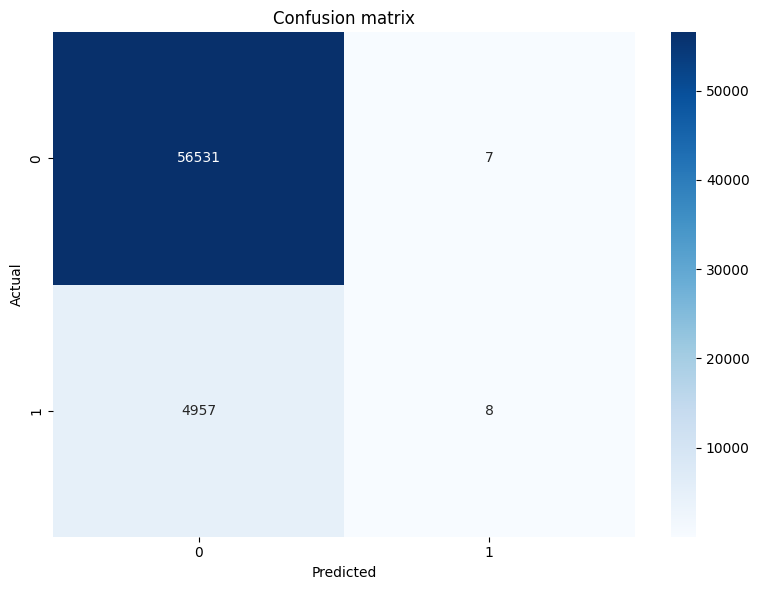

In [26]:
#Run model Predict for eval 
y_pred_probs = model.predict(X_test_processed)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()   #simple threshold 0.5

class_names = ["0","1"]     #TARGET is 0,1
n_classes = len(class_names)

#Plot a confusion matrix and evaluate
print(f'Test samples: {len(y_test)}')
print(f'Prediction distribution:')
print(f'  Actual:    {Counter(y_test)}')
print(f'  Predicted: {Counter(y_pred)}')
print(f'Classification Report: ')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Confusion matrix')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, 
    annot=True, fmt='d', cmap='Blues', 
    xticklabels=class_names, yticklabels=class_names, ax=ax
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


Evaluating our results we have a very low True Positive catch rate. This is expected because if we remember the class balance from earlier only ~8.0729% of users defaulted. Our baseline model loss is assuming equal class weights. Our accuracy looks good at 92% but that's not helpful, the model is just predicting everyone as repaid/non-default and due to the class imbalance, on paper this looks fine, but misleading.

Our recall is ~0.001=(5 / 4960), but this is rounded to 0 and 1.0. While our precision is ~0.45=(5/11) which again, due to class imbalance the model rarely predicts 1 this in turn,  hurts the interpretation of this metric as well.

Looking back at our training AUC on epoch 9 was 0.7291 so the model CAN rank risk, it's not just flipping a coin. Our threshold is adjusted poorly, we can consider sliding this to have our baseline perform way better. 

### 2.6 CM2 Threshold Tuning 

Test samples: 61503
Prediction distribution:
  Actual:    Counter({0: 56538, 1: 4965})
  Predicted: Counter({np.int64(0): 39649, np.int64(1): 21854})
Classification Report: 
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     56538
           1       0.15      0.67      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.56      0.67      0.52     61503
weighted avg       0.89      0.67      0.75     61503



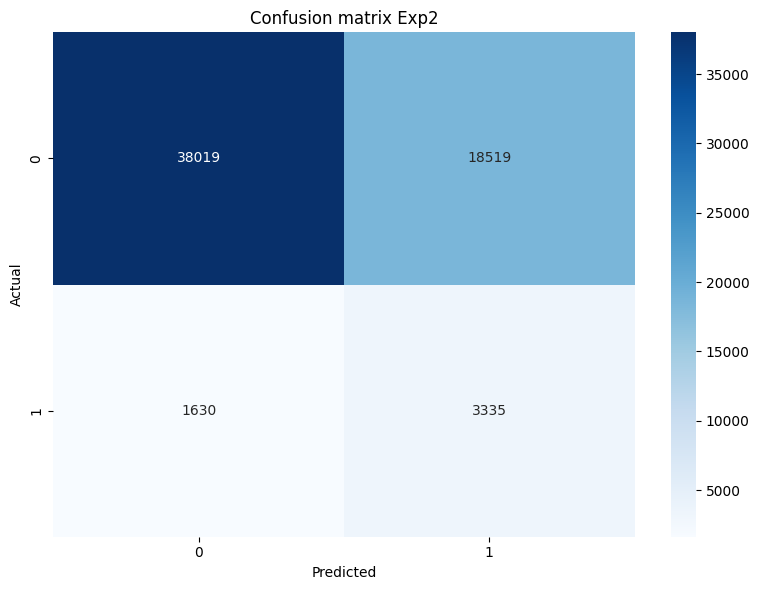

In [27]:
#Run model predict at a 0.1 threshold to see the difference
y_pred_adjusted = (y_pred_probs > 0.1).astype(int).flatten()

print(f'Test samples: {len(y_test)}')
print(f'Prediction distribution:')
print(f'  Actual:    {Counter(y_test)}')
print(f'  Predicted: {Counter(y_pred_adjusted)}')
print(f'Classification Report: ')
print(classification_report(y_test, y_pred_adjusted))

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Confusion matrix Exp2')
cm2 = confusion_matrix(y_test, y_pred_adjusted)
sns.heatmap(
    cm2, 
    annot=True, fmt='d', cmap='Blues', 
    xticklabels=class_names, yticklabels=class_names, ax=ax
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

As we can see and expected, at a threshold of 0.1 to be closer to the ~8% of defaults. This tuning leaning far more to the right our model was able to help our recall significantly from our previous distribution up to ~0.60=(2999/4965). While our precision lowered a bit to ~0.17=(2999/17885) as expected as a trade-off for a better recall distribution. This is a reminder of threshold tuning being very important when deciding model evaluations. 

## 3. Feature Engineering
- Focus on our top correlated features to engineer for signals
- Look back into our boxplot of income graph from earlier

In [28]:
# reminder of top correlated features
print(top_corr_features)

['DAYS_BIRTH', 'REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']


In [29]:
df_engineered = df.copy(deep=True)
df_engineered

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### 3.1 Create Age 
- Create Ages Feature
- Bin Ages by -> [0, 18, 25, 45, 65, 120]

In [30]:
# Create AGE_YEARS and AGE_GROUP
df_engineered["AGE_YEARS"] = abs(df_engineered["DAYS_BIRTH"]) / 365 #ABS the Negative valued days and divide for years

df_engineered['AGE_GROUP'] = pd.cut(
    df_engineered['AGE_YEARS'],
    bins=[0, 18, 25, 45, 65, 120],
    labels=['Child', 'Young Adult', 'Adult', 'Middle Age', 'Senior']
)
df_engineered

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,AGE_GROUP
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548,Adult
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507,Middle Age
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

We created an age group and age years category for better interpretability and signal for our data.

### 3.2 Create Income Ratios
- Income ratios with Credit and Annuity
- Goods to credit

In [31]:
income_cols = [
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

print(f"Description of Income Columns:")
print(df_dictionary[df_dictionary["Variable Name"].isin(income_cols) == True]["Description"].values)

#Loan to income ratios
df_engineered["LOAN_TO_INCOME"] = (
    df_engineered["AMT_CREDIT"] / df_engineered["AMT_INCOME_TOTAL"]
)

#Annuity to income ratios
df_engineered["ANNUITY_TO_INCOME"] = (
    df_engineered["AMT_ANNUITY"] / df_engineered["AMT_INCOME_TOTAL"]
)

#Goods to credit ratios
df_engineered["GOODS_TO_CREDIT"] = (
    df_engineered["AMT_GOODS_PRICE"] / df_engineered["AMT_CREDIT"]
)

df_engineered

Description of Income Columns:
<StringArray>
[                 'Total income of the applicant.',
                'Total credit amount of the loan.',
                 'Loan annuity (monthly payment).',
 'Price of the goods for which the loan is taken.']
Length: 4, dtype: str


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,AGE_GROUP,LOAN_TO_INCOME,ANNUITY_TO_INCOME,GOODS_TO_CREDIT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548,Adult,2.007889,0.121978,0.863262
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507,Middle Age,4.790750,0.132217,0.873211
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY

We created income ratios to strongly display a predictor of an at risk defaulter. It shows us a direct measure of repayment capacity, unlike credit scores which use historical behavior, this shows us CURRENT ability to pay for i.e. monthly payments. Having a low DTI (Debt to Income) <35% indicates a healthy balance that the user can pay off the loan. Higher DTI >50% is a strong indication of a potential defaulter. 

### 3.3 Create Credit Bureau
- Create a summation of the bureau features this is a signal of how often users seek credit, higher summations equates to higher risks.

In [32]:
bureau_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

print(f"Description of Bureau Columns:")
print(df_dictionary[df_dictionary["Variable Name"].isin(bureau_cols) == True]["Description"].values)

#Add the bureau cols back into the engineered df with fillna 0 since that's the same as missing values here
df_engineered["TOTAL_BUREAU_REQUESTS"] = df_engineered[bureau_cols].fillna(0).sum(axis=1)
df_engineered

Description of Bureau Columns:
<StringArray>
[   'Number of inquiries to the Credit Bureau in the last hour.',
     'Number of inquiries to the Credit Bureau in the last day.',
    'Number of inquiries to the Credit Bureau in the last week.',
   'Number of inquiries to the Credit Bureau in the last month.',
 'Number of inquiries to the Credit Bureau in the last quarter.',
    'Number of inquiries to the Credit Bureau in the last year.']
Length: 6, dtype: str


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,AGE_GROUP,LOAN_TO_INCOME,ANNUITY_TO_INCOME,GOODS_TO_CREDIT,TOTAL_BUREAU_REQUESTS
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548,Adult,2.007889,0.121978,0.863262,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507,Middle Age,4.790750,0.132217,0.873211,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1

We created a summation of the number of inquiry hits a user has taken recently, giving us a real-time snapshot of their recent activity trying to find a loan.

### 3.4 Create Ext Source Aggregates

In [33]:
#Add ext_source aggregated features
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

print(f"Description of Ext Columns:")
print(df_dictionary[df_dictionary["Variable Name"].isin(ext_cols) == True]["Description"].values)

df_engineered["EXT_SOURCE_MEAN"] = df_engineered[ext_cols].mean(axis=1, skipna=True)
df_engineered["EXT_SOURCE_STD"] = df_engineered[ext_cols].std(axis=1, skipna=True)
df_engineered["EXT_SOURCE_MIN"] = df_engineered[ext_cols].min(axis=1, skipna=True)
df_engineered["EXT_SOURCE_MAX"] = df_engineered[ext_cols].max(axis=1, skipna=True)
df_engineered["EXT_SOURCE_MEDIAN"] = df_engineered[ext_cols].median(axis=1)

# additional powerful signal
df_engineered["EXT_SOURCE_RANGE"] = df_engineered["EXT_SOURCE_MAX"] - df_engineered["EXT_SOURCE_MIN"]

# multiplicative interaction (very powerful)
df_engineered["EXT_SOURCE_PRODUCT"] = (
    df_engineered["EXT_SOURCE_1"] *
    df_engineered["EXT_SOURCE_2"] *
    df_engineered["EXT_SOURCE_3"]
)

df_engineered

Description of Ext Columns:
<StringArray>
[]
Length: 0, dtype: str


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,AGE_GROUP,LOAN_TO_INCOME,ANNUITY_TO_INCOME,GOODS_TO_CREDIT,TOTAL_BUREAU_REQUESTS,EXT_SOURCE_MEAN,EXT_SOURCE_STD,EXT_SOURCE_MIN,EXT_SOURCE_MAX,EXT_SOURCE_MEDIAN,EXT_SOURCE_RANGE,EXT_SOURCE_PRODUCT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548,Adult,2.007889,0.121978,0.863262,1.0,0.161787,0.092026,0.083037,0.262949,0.139376,0.179912,0.003043
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507,Middle Age,4.790750,0.132217,0.873211,0.0,0.466757,0.219895,0.311267

### 3.5 Create Occupation Missing Flag

In [34]:
#Create a flag for unemployed users to see if they default
df_engineered["OCCUPATION_MISSING"] = df_engineered["OCCUPATION_TYPE"].isna().astype(int)
df_engineered

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,AGE_GROUP,LOAN_TO_INCOME,ANNUITY_TO_INCOME,GOODS_TO_CREDIT,TOTAL_BUREAU_REQUESTS,EXT_SOURCE_MEAN,EXT_SOURCE_STD,EXT_SOURCE_MIN,EXT_SOURCE_MAX,EXT_SOURCE_MEDIAN,EXT_SOURCE_RANGE,EXT_SOURCE_PRODUCT,OCCUPATION_MISSING
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548,Adult,2.007889,0.121978,0.863262,1.0,0.161787,0.092026,0.083037,0.262949,0.139376,0.179912,0.003043,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507,Middle Age,4.790750,0.132217,0.873211,0.0,0.466

We created a flag for missing occupation/unemployed users to help predict a default user. This shows the user usually wouldn't have an income to repay their loan or hint at other legalities that would be taken into account.

## 4. Experiment 2: Feature Engineered Model
- Create a Model Function
- Run our model block by block with each feature engineered change. Helps reinforce our engineering choices.
- Evaluate non-engineered features to engineered ones

### 4.1 Define Model Function

In [35]:
df_engineered.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 136 entries, SK_ID_CURR to OCCUPATION_MISSING
dtypes: category(1), float64(77), int64(42), str(16)
memory usage: 317.0 MB


In [36]:
#Create Model Function to train and evaluate
run_count = 0
experiment_results = []

def train_and_evaluate(df_input, experiment_name="Default", threshold=0.1):
    global run_count

    # Separate our TARGET
    X = df_input.drop("TARGET", axis=1)
    y = df_input["TARGET"]

    #train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=320
    )


    #Collect our dtypes for safe pipelining
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X.select_dtypes(include=["str", "category", "object"]).columns

    #Numerical Pipeline
    numerical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    #Categorical Pipeline
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    #Preprocess
    preprocessor = ColumnTransformer([
        ("num", numerical_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ])

    #Transform our data
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    print(f"Shape of training data: {X_train_processed.shape}")
    print(f"Shape of test data: {X_test_processed.shape}")


    #Model Parameters
    input_dim = X_train_processed.shape[1]  #Input Dim
    dropout = 0.2
    output_dim = 1  #Output Filter size
    learning_rate = 1e-3    #LR for fine-tuning
    layer_activation = "relu"

    #Model Creation
    model = Sequential([
        Input((input_dim,)),
        Dropout(dropout),
        Dense(128, activation=layer_activation),
        Dense(64, activation=layer_activation),
        Dropout(dropout),
        Dense(output_dim, activation='sigmoid')  #TARGET is binary
    ])

    model.compile(
        optimizer = tf.optimizers.Adam(learning_rate=learning_rate),
        loss = "binary_crossentropy",
        metrics = [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    model.summary()


    #Callbacks
    callbacks = [
        ModelCheckpoint(
            f'./models/home_loan_engineered_{run_count}.keras',
            save_best_only=True,
            monitor='val_auc',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        TensorBoard(
            log_dir=f'./logs/home_loan_engineered_{run_count}',
            histogram_freq=1,
            write_graph=True
        )
    ]
    run_count += 1


    #Train
    history = model.fit(
        X_train_processed,  #training data
        y_train,    #Target data
        validation_split=0.2,
        epochs=20,
        batch_size=1024,    #246008 training rows
        verbose=1,
        callbacks=callbacks
    )


    #Run model Predict for eval 
    y_pred_probs = model.predict(X_test_processed)
    y_pred = (y_pred_probs > threshold).astype(int).flatten()

    #Metrics
    report = classification_report(y_test, y_pred)
    print(f'Classification Report: ')
    print(report)

    auc = roc_auc_score(y_test, y_pred_probs.flatten())
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    #Cache run results
    experiment_results.append({
        "Experiment": experiment_name,
        "AUC": auc,
        "Precision":precision,
        "Recall":recall,
        "F1":f1
    })

    return history

### 4.2 Age Feature

In [37]:
#Copy and add age feature
df_age = df_baseline.copy(deep=True)
df_age["AGE_YEARS"] = abs(df_age["DAYS_BIRTH"]) / 365 #ABS the Negative valued days and divide for years

df_age['AGE_GROUP'] = pd.cut(
    df_age['AGE_YEARS'],
    bins=[0, 18, 25, 45, 65, 120],
    labels=['Child', 'Young Adult', 'Adult', 'Middle Age', 'Senior']
)

#Run model function with only age added
train_and_evaluate(df_age, "Age Features")

Shape of training data: (246008, 229)
Shape of test data: (61503, 229)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_2 (Dropout)             │ (None, 229)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,761 (147.50 KB)

 Trainable params: 37,761 (147.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
188/193 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8987 - auc: 0.6041 - loss: 0.3162 - precision: 0.0775 - recall: 0.0239
Epoch 1: val_auc improved from None to 0.73590, saving model to ./models/home_loan_engineered_0.keras

Epoch 1: finished saving model to ./models/home_loan_engineered_0.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9153 - auc: 0.6591 - loss: 0.2786 - precision: 0.0793 - recall: 0.0046 - val_accuracy: 0.9194 - val_auc: 0.7359 - val_loss: 0.2544 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
189/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9196 - auc: 0.7080 - loss: 0.2605 - precision: 0.4749 - recall: 0.0013
Epoch 2: val_auc improved from 0.73590 to 0.74077, saving model to ./models/home_loan_engineered_0.keras

Epoch 2: finished saving model to ./models/home_loan_engineered_0.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9192 - auc: 0.7105 - loss: 0.2598 - precision: 0.4490 - recall: 0.0014 - val_ac

### 4.3 Income Ratio Features

In [38]:
#Copy age df and add ratios
income_cols = [
    "AMT_CREDIT",
    "AMT_INCOME_TOTAL",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

df_ratios = df_age.copy(deep=True)

#Loan to income ratios
df_ratios["LOAN_TO_INCOME"] = (
    df_ratios["AMT_CREDIT"] / df_ratios["AMT_INCOME_TOTAL"]
)

#Annuity to income ratios
df_ratios["ANNUITY_TO_INCOME"] = (
    df_ratios["AMT_ANNUITY"] / df_ratios["AMT_INCOME_TOTAL"]
)

#Goods to credit ratios
df_ratios["GOODS_TO_CREDIT"] = (
    df_ratios["AMT_GOODS_PRICE"] / df_ratios["AMT_CREDIT"]
)

#Run model function with ratios added
train_and_evaluate(df_ratios, "Income Ratio Features")

Shape of training data: (246008, 232)
Shape of test data: (61503, 232)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_4 (Dropout)             │ (None, 232)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        29,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,145 (149.00 KB)

 Trainable params: 38,145 (149.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
192/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8630 - auc: 0.6005 - loss: 0.3518 - precision: 0.0833 - recall: 0.0709
Epoch 1: val_auc improved from None to 0.73737, saving model to ./models/home_loan_engineered_1.keras

Epoch 1: finished saving model to ./models/home_loan_engineered_1.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9076 - auc: 0.6588 - loss: 0.2865 - precision: 0.0854 - recall: 0.0148 - val_accuracy: 0.9194 - val_auc: 0.7374 - val_loss: 0.2535 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
186/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9196 - auc: 0.7074 - loss: 0.2607 - precision: 0.4854 - recall: 7.7097e-04
Epoch 2: val_auc improved from 0.73737 to 0.74052, saving model to ./models/home_loan_engineered_1.keras

Epoch 2: finished saving model to ./models/home_loan_engineered_1.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9192 - auc: 0.7108 - loss: 0.2600 - precision: 0.4800 - recall: 7.5495e-04 

### 4.4 Credit Bureau Features

In [39]:
#Copy ratios df and add bureau features
bureau_cols = [
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
]

df_bureaus = df_ratios.copy(deep=True)

df_bureaus["TOTAL_BUREAU_REQUESTS"] = df_bureaus[bureau_cols].fillna(0).sum(axis=1)

#Run model with bureaus added
train_and_evaluate(df_bureaus, "Credit Bureau Features")

Shape of training data: (246008, 233)
Shape of test data: (61503, 233)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_6 (Dropout)             │ (None, 233)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        29,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,273 (149.50 KB)

 Trainable params: 38,273 (149.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
191/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8691 - auc: 0.5998 - loss: 0.3456 - precision: 0.0888 - recall: 0.0674
Epoch 1: val_auc improved from None to 0.74008, saving model to ./models/home_loan_engineered_2.keras

Epoch 1: finished saving model to ./models/home_loan_engineered_2.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9092 - auc: 0.6561 - loss: 0.2856 - precision: 0.0902 - recall: 0.0137 - val_accuracy: 0.9194 - val_auc: 0.7401 - val_loss: 0.2531 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
184/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9195 - auc: 0.7074 - loss: 0.2615 - precision: 0.2516 - recall: 6.5172e-04
Epoch 2: val_auc improved from 0.74008 to 0.74332, saving model to ./models/home_loan_engineered_2.keras

Epoch 2: finished saving model to ./models/home_loan_engineered_2.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9192 - auc: 0.7090 - loss: 0.2606 - precision: 0.3077 - recall: 5.0330e-04 

### 4.5 Ext Source Features

In [40]:
#Copy bureaus df and add ext source features
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

df_ext_source = df_bureaus.copy(deep=True)

df_ext_source["EXT_SOURCE_MEAN"] = df_ext_source[ext_cols].mean(axis=1, skipna=True)
df_ext_source["EXT_SOURCE_STD"] = df_ext_source[ext_cols].std(axis=1, skipna=True)
df_ext_source["EXT_SOURCE_MIN"] = df_ext_source[ext_cols].min(axis=1, skipna=True)
df_ext_source["EXT_SOURCE_MAX"] = df_ext_source[ext_cols].max(axis=1, skipna=True)
df_ext_source["EXT_SOURCE_MEDIAN"] = df_ext_source[ext_cols].median(axis=1)

# additional powerful signal
df_ext_source["EXT_SOURCE_RANGE"] = df_ext_source["EXT_SOURCE_MAX"] - df_ext_source["EXT_SOURCE_MIN"]

# multiplicative interaction (very powerful)
df_ext_source["EXT_SOURCE_PRODUCT"] = (
    df_ext_source["EXT_SOURCE_1"] *
    df_ext_source["EXT_SOURCE_2"] *
    df_ext_source["EXT_SOURCE_3"]
)

#Run model with ext sources added
train_and_evaluate(df_ext_source, "Ext Source Features")

Shape of training data: (246008, 240)
Shape of test data: (61503, 240)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_8 (Dropout)             │ (None, 240)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        30,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,169 (153.00 KB)

 Trainable params: 39,169 (153.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
185/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9103 - auc: 0.6434 - loss: 0.2988 - precision: 0.0990 - recall: 0.0122
Epoch 1: val_auc improved from None to 0.74225, saving model to ./models/home_loan_engineered_3.keras

Epoch 1: finished saving model to ./models/home_loan_engineered_3.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9176 - auc: 0.6908 - loss: 0.2706 - precision: 0.1158 - recall: 0.0031 - val_accuracy: 0.9194 - val_auc: 0.7423 - val_loss: 0.2531 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
193/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9196 - auc: 0.7250 - loss: 0.2584 - precision: 0.3196 - recall: 8.5257e-04
Epoch 2: val_auc improved from 0.74225 to 0.74503, saving model to ./models/home_loan_engineered_3.keras

Epoch 2: finished saving model to ./models/home_loan_engineered_3.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9192 - auc: 0.7248 - loss: 0.2570 - precision: 0.4314 - recall: 0.0014 - va

### 4.6 Occupation Missing

In [41]:
#Copy ext source df and add occupation missing feature
df_occupation = df_ext_source.copy(deep=True)

df_occupation["OCCUPATION_MISSING"] = df_occupation["OCCUPATION_TYPE"].isna().astype(int)

#Run model with ext sources added
train_and_evaluate(df_occupation, "Occupation Missing Features")

Shape of training data: (246008, 241)
Shape of test data: (61503, 241)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_10 (Dropout)            │ (None, 241)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        30,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,297 (153.50 KB)

 Trainable params: 39,297 (153.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
183/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8953 - auc: 0.6278 - loss: 0.3168 - precision: 0.0951 - recall: 0.0334
Epoch 1: val_auc improved from None to 0.74211, saving model to ./models/home_loan_engineered_4.keras

Epoch 1: finished saving model to ./models/home_loan_engineered_4.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9148 - auc: 0.6807 - loss: 0.2755 - precision: 0.1016 - recall: 0.0070 - val_accuracy: 0.9194 - val_auc: 0.7421 - val_loss: 0.2530 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
186/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9196 - auc: 0.7197 - loss: 0.2583 - precision: 0.4554 - recall: 0.0025
Epoch 2: val_auc improved from 0.74211 to 0.74574, saving model to ./models/home_loan_engineered_4.keras

Epoch 2: finished saving model to ./models/home_loan_engineered_4.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9192 - auc: 0.7242 - loss: 0.2568 - precision: 0.4898 - recall: 0.0030 - val_ac

### 4.7 Evaluate Changes
- Check individual feature changes
- Train on full engineered data

In [42]:
#Compare all experiment cached results
pd.DataFrame(experiment_results).sort_values("AUC", ascending=False)

,Experiment,AUC,Precision,Recall,F1
4,Occupation Missing Features,0.746794,0.158244,0.672910,0.256231
3,Ext Source Features,0.743768,0.158188,0.669486,0.255909
2,Credit Bureau Features,0.740616,0.154693,0.670493,0.251388
1,Income Ratio Features,0.739570,0.154595,0.674522,0.251540
0,Age Features,0.736529,0.157902,0.658006,0.254687


We have ran each feature block individually and found that each feature added in fact DID increase or have some signal strength on our data. We reinforced our engineering changes had an impact. Looking at our top AUC result being ext_source features the recall we catch 56% of defaulters. This is our most important stat to pay attention to because for finance we want to confidently catch default users. Let's see if this improves with all features already added.

In [43]:
#train and eval df_engineered with all features included
train_and_evaluate(df_engineered, "Full Engineered Features")

Shape of training data: (246008, 268)
Shape of test data: (61503, 268)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_12 (Dropout)            │ (None, 268)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        34,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,753 (167.00 KB)

 Trainable params: 42,753 (167.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
188/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9186 - auc: 0.6555 - loss: 0.2830 - precision: 0.2832 - recall: 0.0055
Epoch 1: val_auc improved from None to 0.74123, saving model to ./models/home_loan_engineered_5.keras

Epoch 1: finished saving model to ./models/home_loan_engineered_5.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9189 - auc: 0.6950 - loss: 0.2669 - precision: 0.3386 - recall: 0.0040 - val_accuracy: 0.9194 - val_auc: 0.7412 - val_loss: 0.2533 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
182/193 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9196 - auc: 0.7229 - loss: 0.2574 - precision: 0.4396 - recall: 0.0021
Epoch 2: val_auc improved from 0.74123 to 0.74442, saving model to ./models/home_loan_engineered_5.keras

Epoch 2: finished saving model to ./models/home_loan_engineered_5.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9192 - auc: 0.7243 - loss: 0.2570 - precision: 0.4035 - recall: 0.0014 - val_ac

Evaluating on our fully engineered dataframe we see that recall increased all the way to 61% catch rate. This is a good jump, problem is it's still very close to our previous baseline model at threshold 0.1, we can improve signal. Our precision is also lacking, let's try to optimize by updating class weights, thresholds, and Dense layers.

## 5. Optimization Improvements

### 5.1 Compute Class Weights and Thresholds

In [44]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')

Class weights: {0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}


In [45]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)

Best Threshold: 0.58071977


C:\Users\gahhh\AppData\Local\Temp\ipykernel_68296\3093080354.py:3: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


### 5.2 Create Optimized Model Function

In [46]:
#Create optimized Model Function to train and evaluate
run_count_opt = 0
opt_experiment_results = []

def opt_train_and_evaluate(df_input, experiment_name="Default"):
    global run_count_opt

    # Separate our TARGET
    X = df_input.drop("TARGET", axis=1)
    y = df_input["TARGET"]

    #train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=320
    )


    #Collect our dtypes for safe pipelining
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X.select_dtypes(include=["str", "category", "object"]).columns

    #Numerical Pipeline
    numerical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    #Categorical Pipeline
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    #Preprocess
    preprocessor = ColumnTransformer([
        ("num", numerical_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ])

    #Transform our data
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    print(f"Shape of training data: {X_train_processed.shape}")
    print(f"Shape of test data: {X_test_processed.shape}")


    #Model Parameters
    input_dim = X_train_processed.shape[1]  #Input Dim
    dropout = 0.2
    output_dim = 1  #Output Filter size
    learning_rate = 1e-3    #LR for fine-tuning
    layer_activation = "relu"

    #Model Creation
    model = Sequential([
        Input((input_dim,)),
        Dropout(dropout),
        BatchNormalization(),
        Dense(256, activation=layer_activation),
        Dropout(dropout),
        Dense(128, activation=layer_activation),
        Dropout(dropout),
        Dense(64, activation=layer_activation),
        Dropout(dropout),
        Dense(output_dim, activation='sigmoid')  #TARGET is binary
    ])

    model.compile(
        optimizer = tf.optimizers.Adam(learning_rate=learning_rate),
        loss = "binary_crossentropy",
        metrics = [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    model.summary()

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))
    print(f'Class weights: {class_weight_dict}')


    #Callbacks
    callbacks = [
        ModelCheckpoint(
            f'./models/home_loan_optimized_{run_count_opt}.keras',
            save_best_only=True,
            monitor='val_auc',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        TensorBoard(
            log_dir=f'./logs/home_loan_optimized_{run_count_opt}',
            histogram_freq=1,
            write_graph=True
        )
    ]
    run_count_opt += 1


    #Train
    history = model.fit(
        X_train_processed,  #training data
        y_train,    #Target data
        validation_split=0.2,
        epochs=20,
        batch_size=1024,    #246008 training rows
        class_weight=class_weight_dict,
        verbose=1,
        callbacks=callbacks
    )


    #Run model Predict for eval 
    y_pred_probs = model.predict(X_test_processed)

    #Get Best threshold instead of guessing
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_threshold = thresholds[np.argmax(f1_scores)]
    print("Best Threshold:", best_threshold)

    y_pred = (y_pred_probs > best_threshold).astype(int).flatten()

    #Metrics
    report = classification_report(y_test, y_pred)
    print(f'Classification Report: ')
    print(report)

    auc = roc_auc_score(y_test, y_pred_probs.flatten())
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    #Cache run results
    opt_experiment_results.append({
        "Experiment": experiment_name,
        "AUC": auc,
        "Precision":precision,
        "Recall":recall,
        "F1":f1,
        "Best_Threshold": best_threshold,
        "Predicts": y_pred,
        "True_Values": y_test,
        "Pred_Probs": y_pred_probs
    })

    return history

### 5.3 Optimized Training

In [47]:
#Train optimized function
history = opt_train_and_evaluate(df_engineered, "Full Engineered Optimized")
history

Shape of training data: (246008, 268)
Shape of test data: (61503, 268)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_14 (Dropout)            │ (None, 268)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 268)            │         1,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │        68,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,153 (434.19 KB)

 Trainable params: 110,617 (432.10 KB)

 Non-trainable params: 536 (2.09 KB)

Class weights: {0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}
Epoch 1/20
190/193 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6189 - auc: 0.6702 - loss: 0.6513 - precision: 0.1275 - recall: 0.6361
Epoch 1: val_auc improved from None to 0.74419, saving model to ./models/home_loan_optimized_0.keras

Epoch 1: finished saving model to ./models/home_loan_optimized_0.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6437 - auc: 0.7052 - loss: 0.6296 - precision: 0.1399 - recall: 0.6625 - val_accuracy: 0.6551 - val_auc: 0.7442 - val_loss: 0.6361 - val_precision: 0.1508 - val_recall: 0.7082
Epoch 2/20
188/193 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6727 - auc: 0.7323 - loss: 0.6065 - precision: 0.1533 - recall: 0.6788
Epoch 2: val_auc improved from 0.74419 to 0.74680, saving model to ./models/home_loan_optimized_0.keras

Epoch 2: finished saving model to ./models/home_loan_optimized_0.keras
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6713 -

We modified our above function to include our example functions **compute_class_weight** and **precision_recall_curve** to answer our imbalanced class weights and improper threshold setting. Then we added another Dense layer and added more dropouts throughout our model architecture to keep the model learning without overfitting. These changes combined were **HUGE** in our final results. We learned that keeping our threshold at 0.1 after class weight changes forced a lot of false positives, where the model always assumed a user would default. This gave us a 1.0 recall but very low precision(and possible angry customers). Giving our model a **precision_recall_curve** to find the best threshold helped curb this class bias change and move it closer towards the middle at 0.5.

- At threshold 0.1
Classification Report:

| --- |precision | recall |  f1-score |  support  |
|---|---|---|---|---|
| 0 |  0.99   | 0.01  |  0.02   |  56538  |
| 1 |  0.08  |  1.00   | 0.15 |  4965  |
| accuracy |   |   |   0.09   |  61503  |
| macro avg | 0.54 |   0.51   | 0.09 |  61503  |
| weighted avg | 0.92 | 0.09 | 0.03 |  61503  |



Test samples: 61503
Prediction distribution:
  Actual:    Counter({0: 56538, 1: 4965})
  Predicted: Counter({np.int64(0): 53065, np.int64(1): 8438})
Classification Report: 
              precision    recall  f1-score   support

           0       0.94      0.89      0.91     56538
           1       0.23      0.39      0.29      4965

    accuracy                           0.85     61503
   macro avg       0.59      0.64      0.60     61503
weighted avg       0.89      0.85      0.86     61503



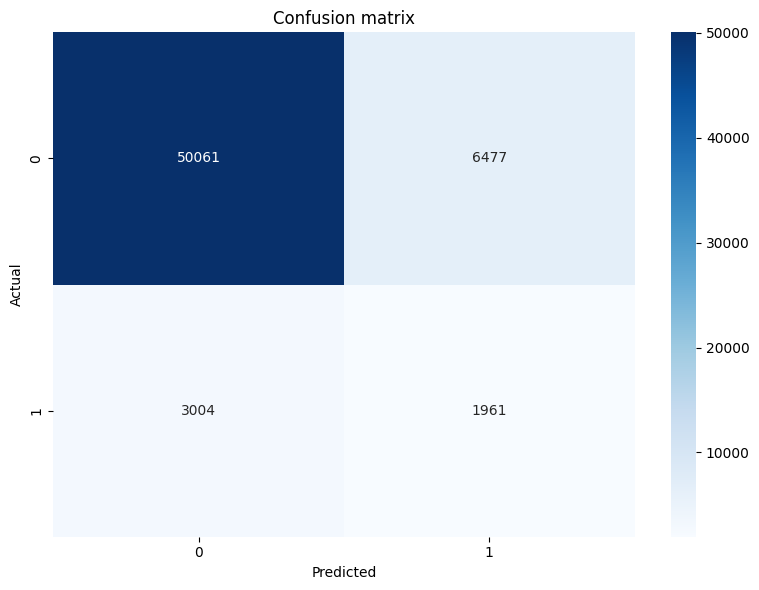

In [48]:
#Get model values for eval
y_pred = opt_experiment_results[-1]["Predicts"]
y_test = opt_experiment_results[-1]["True_Values"]
y_pred_probs = opt_experiment_results[-1]["Pred_Probs"]


class_names = ["0","1"]     #TARGET is 0,1
n_classes = len(class_names)

#Plot a confusion matrix and evaluate
print(f'Test samples: {len(y_test)}')
print(f'Prediction distribution:')
print(f'  Actual:    {Counter(y_test)}')
print(f'  Predicted: {Counter(y_pred)}')
print(f'Classification Report: ')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Confusion matrix')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, 
    annot=True, fmt='d', cmap='Blues', 
    xticklabels=class_names, yticklabels=class_names, ax=ax
)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

Looking at our final confusion matrix we lose a lot more false positives at the cost of losing half of the true positives. This is unavoidable and is the cost of precision-recall tradeoff. This begs a business question, do we care about false flags? or do we care more about costs? What happens when a user defaults goes through?

### 5.4 ROC Curve

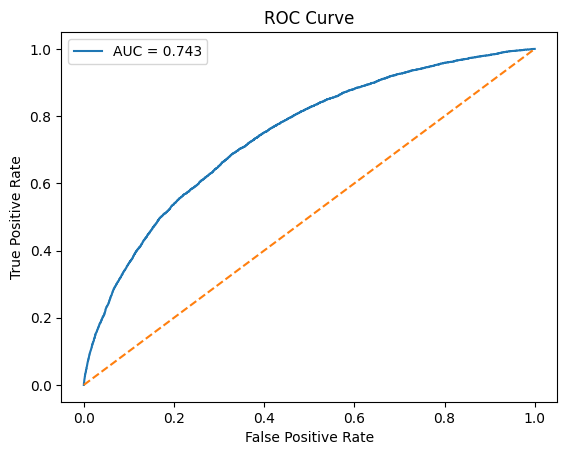

In [49]:
#Plot an ROC curve from optimized model data
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### 5.5 Precision-Recall Curve

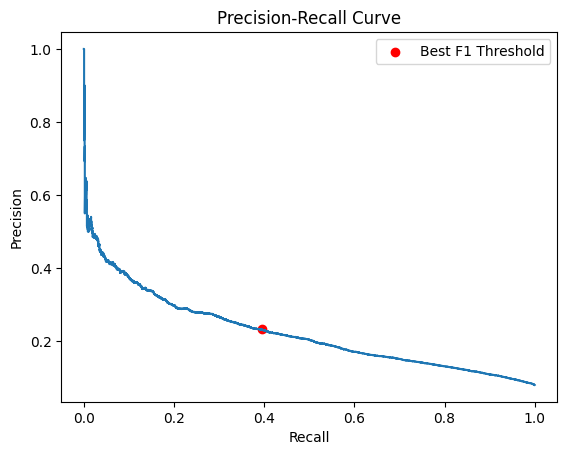

In [50]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_probs)

#Make a marker for best threshold
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)
best_index = f1_scores.argmax()
best_precision = precision_vals[best_index]
best_recall = recall_vals[best_index]

#Plot curve
plt.plot(recall_vals, precision_vals)

#Plot Best threshold dot
plt.scatter(
    best_recall,
    best_precision,
    color="red",
    label="Best F1 Threshold"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

Our Precision-Recall curve shows how quickly precision drops once recall increases marking the unavoidable tradeoff when dealing with classifiers. This also showcases where our threshold tuning was looking as we explored and tried different values.

## 6. Discussion

### 6.1 EDA
We began by looking at all the data and sampling immediately to do a quick scan of the data to find there were many missing values throughout the many features. We took note of features of interest such as normalized features or feature names that related to a loan such as income. We proceeded to visualize some of our features mainly income and our target which was default users. Utilized the df_dictionary to understand the data even further as to not be misinterpreted. Creating a correlation map was a HUGE guide further into features of interest. Overall, this correlation graph helped immensely in determining strong signals for our target.

### 6.2 Baseline Model
Going into a simple baseline model we developed a feedforward neural network. Our data was a snapshot in time, so no need for sequential friendly RNNs. This also crossed out the need for the spatial friendly CNNs we aren't looking at spatial data. We used our fundamentals and utilized the safe preprocessing sklearn provides with pipelines and column transformers. Our model was a binary problem of default or not so our loss was binary_crossentrophy and optimized with the standard adam optimizer. Accuracy is not reliable for classifying so we monitored the metric AUC, precisions, and recalls.

### 6.3 Feature Engineering
Now, feature engineering our data we had to do similar thought processes as EDA but with the newfound knowledge correlations gave us. We reevaluated features that seemed relevant i.e. age, income, credit hits, ext_sources, job titles. These all were researched and revisited with how could this affect a user defaulting on a loan. Using aggregation, categorical grouping, flag creations and ratios, we were able to create stronger signals to help our model learn patterns. Although each feature engineered helped we only slightly improved our AUC.

### 6.4 Optimization
Optimization focused on fully changing the model's architecture, class imbalances, and thresholds to improve. We no longer needed feature engineering done, we proved these helped our model. We tested our static hyper-parameters i.e. 0.1 threshold and optimized this further with our Precision-Recall curve to stop guessing. We had to make a decision to balance the tradeoff when pushing the class weights too far to the right and forcing the model to assume everyone was a default user. We created a good balanced trade-off for loan risk predictions